# Credit Risk Scoring — End-to-End Walkthrough

A probability-of-default model with the full governance loop a real lender requires:

1. **Data** — 800K simulated applications with correlated bureau-style features and *controlled bias injection* (so fairness tests have ground truth). A companion pipeline runs real Home Credit data.
2. **Models** — incumbent WOE scorecard vs LightGBM / XGBoost / FT-Transformer challengers.
3. **Evaluation** — Gini/KS with bootstrap CIs, calibration, cumulative capture.
4. **Fairness** — adverse-impact ratio (four-fifths rule), equal opportunity, calibration-by-group; a biased feature is caught and removed.
5. **Explainability** — SHAP global behavior + per-applicant adverse-action reason codes (ECOA/Reg B style).
6. **Business impact** — swap-set analysis: $ losses at constant volume, approval expansion at constant risk.

> This notebook runs on a 120K sample for speed; headline numbers from the full 800K run are loaded from `reports/metrics.json` at the end. Reproduce everything with `python scripts/run_pipeline.py`.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

from creditrisk import config as C, viz
from creditrisk.data.simulate import simulate_applicants
viz.set_style()

N = 120_000
df = simulate_applicants(N)
df.head()

/home/ubuntu/credit-risk-model/.venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


,application_id,gender,group,age_band,age,annual_income,employment_years,employment_type,credit_history_months,num_credit_lines,...,inquiries_6m,savings_balance,monthly_expenses,loan_amount,loan_to_income,loan_purpose,home_ownership,geo_risk_index,true_pd,default
0,1,male,A,51-65,55.0,29100.0,25.6,self_employed,271.0,5,...,0,16190.0,1070.0,4400.0,0.1512,medical,mortgage,54.6,0.001172,0
1,2,female,A,65+,82.0,32000.0,27.7,salaried,600.0,9,...,0,24410.0,1620.0,6900.0,0.2156,small_business,mortgage,56.4,0.002682,0
2,3,male,B,65+,66.0,13900.0,13.0,salaried,382.0,1,...,2,400.0,540.0,1000.0,0.0719,debt_consolidation,mortgage,78.9,0.016225,0
3,4,male,A,51-65,53.0,18100.0,1.4,contract,167.0,2,...,0,320.0,610.0,1900.0,0.1050,home_improvement,rent,55.8,0.669484,1
4,5,female,A,51-65,52.0,46000.0,18.5,self_employed,362.0,7,...,0,1750.0,1270.0,1400.0,0.0304,debt_consolidation,own,64.4,0.015056,0


## 1. The simulated portfolio

Features are noisy transforms of three latent factors (financial stability, credit experience, debt pressure), so the correlation structure resembles real bureau data. True default risk is dominated by **regime interactions** whose per-feature marginals roughly cancel — e.g. high utilization is dangerous for a distressed revolver but benign for a transactor. An additive binned scorecard structurally cannot express that; a GBM can. That's the challenger's headroom, by design.

default rate: 8.04%


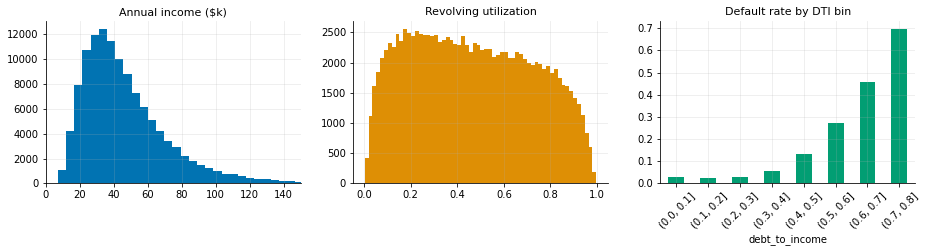

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(df["annual_income"]/1000, bins=80, color="#0173B2"); axes[0].set(title="Annual income ($k)", xlim=(0,150))
axes[1].hist(df["revolving_utilization"], bins=60, color="#DE8F05"); axes[1].set(title="Revolving utilization")
df.groupby(pd.cut(df["debt_to_income"], np.arange(0,0.9,0.1)), observed=True)["default"].mean().plot(
    kind="bar", ax=axes[2], color="#029E73", rot=45); axes[2].set(title="Default rate by DTI bin")
plt.tight_layout()
print(f"default rate: {df['default'].mean():.2%}")

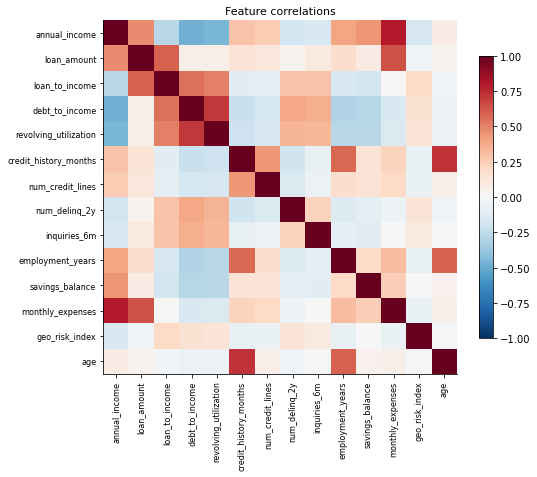

In [3]:
corr = df[C.NUMERIC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
plt.colorbar(im, shrink=0.8); ax.set_title("Feature correlations"); ax.grid(False)

### Fairness ground truth

Protected attributes are **causally inert by construction** — `true_pd` is independent of group and gender. Bias enters only through two parameterized mechanisms:

- **Proxy**: `geo_risk_index` (a regional default-rate index) is shifted upward for group B independent of repayment — the classic redlining mechanism;
- **Measurement**: group B's *reported* income understates true income.

Because the knobs are explicit, the fairness suite can be validated: it must flag the biased configuration and pass the clean one (`tests/test_pipeline.py`).

In [4]:
print("mean true PD by group :", df.groupby("group")["true_pd"].mean().round(4).to_dict())
print("mean true PD by gender:", df.groupby("gender")["true_pd"].mean().round(4).to_dict())
print("geo_risk_index by group:", df.groupby("group")["geo_risk_index"].mean().round(1).to_dict(),
      " <- injected proxy shift")
print("reported income by group:", df.groupby("group")["annual_income"].mean().round(0).to_dict(),
      " <- injected measurement bias")

mean true PD by group : {'A': 0.0807, 'B': 0.0761}
mean true PD by gender: {'female': 0.0797, 'male': 0.0802}
geo_risk_index by group: {'A': 51.2, 'B': 73.4}  <- injected proxy shift
reported income by group: {'A': 48668.0, 'B': 39104.0}  <- injected measurement bias


## 2. Models: incumbent scorecard vs challengers

The incumbent is what most lenders actually run: coarse quantile bins → weight-of-evidence → logistic regression → points scaling (PDO 20). The challengers are LightGBM and XGBoost (and, in the full pipeline, an FT-Transformer trained from scratch — see `src/creditrisk/models/tabular_nn.py`).

The naive challenger uses **all** features, including the new `geo_risk_index` alternative-data feature.

In [5]:
from creditrisk.models.scorecard import Scorecard
from creditrisk.models.gbm import train_lightgbm, train_xgboost, predict_gbm
from creditrisk.evaluation import evaluate_model, metrics_table, bootstrap_gini_ci

rng = np.random.default_rng(C.RANDOM_SEED)
idx = rng.permutation(len(df))
n_te, n_va = int(N*0.2), int(N*0.1)
test, valid, train = df.iloc[idx[:n_te]], df.iloc[idx[n_te:n_te+n_va]], df.iloc[idx[n_te+n_va:]]
y_tr, y_va, y_te = train["default"], valid["default"], test["default"].values

SC_NUM = ["annual_income","debt_to_income","revolving_utilization","credit_history_months",
          "num_delinq_2y","inquiries_6m","employment_years","loan_to_income"]
scorecard = Scorecard(n_bins=5).fit(train, y_tr, SC_NUM, ["home_ownership"])

feats = C.ALL_FEATURES
feats_fair = [f for f in feats if f != "geo_risk_index"]
lgbm       = train_lightgbm(train[feats], y_tr, valid[feats], y_va)
xgbm       = train_xgboost(train[feats], y_tr, valid[feats], y_va)
lgbm_fair  = train_lightgbm(train[feats_fair], y_tr, valid[feats_fair], y_va)

preds = {
    "incumbent":          scorecard.predict_proba(test),
    "lightgbm":           predict_gbm(lgbm, test[feats]),
    "xgboost":            predict_gbm(xgbm, test[feats]),
    "lightgbm_mitigated": predict_gbm(lgbm_fair, test[feats_fair]),
}
table = metrics_table([evaluate_model(y_te, p, m) for m, p in preds.items()])
table["gini_lift"] = (table["gini"] - table.loc["incumbent","gini"]).round(4)
table

,auc,gini,ks,brier,default_rate,gini_lift
model,,,,,,
incumbent,0.7853,0.5706,0.4943,0.0588,0.0788,0.0000
lightgbm,0.8641,0.7283,0.5715,0.0512,0.0788,0.1577
xgboost,0.8660,0.7321,0.5727,0.0512,0.0788,0.1615
lightgbm_mitigated,0.8400,0.6800,0.5500,0.0528,0.0788,0.1094


The scorecard's WOE bins recover any *per-feature* shape, but the signal here lives in the joint distribution — hence the structural gap. Note the naive LightGBM beats the mitigated one: that extra Gini is exactly what the biased feature buys, and §4 shows why it has to go.

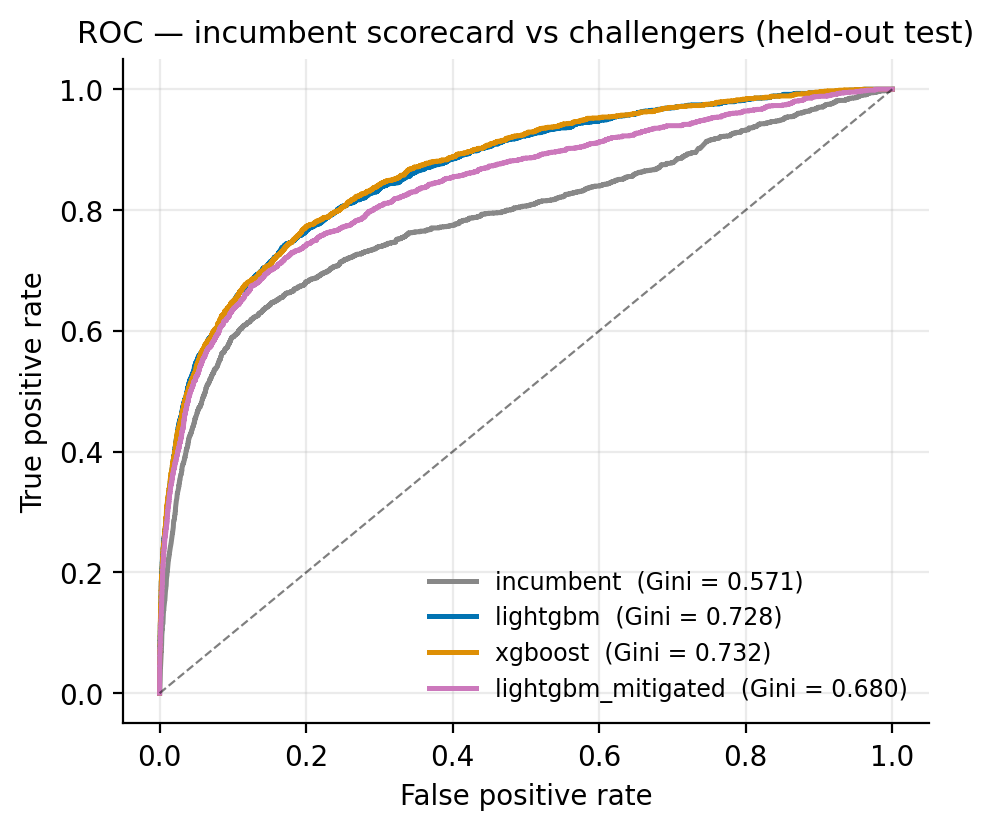

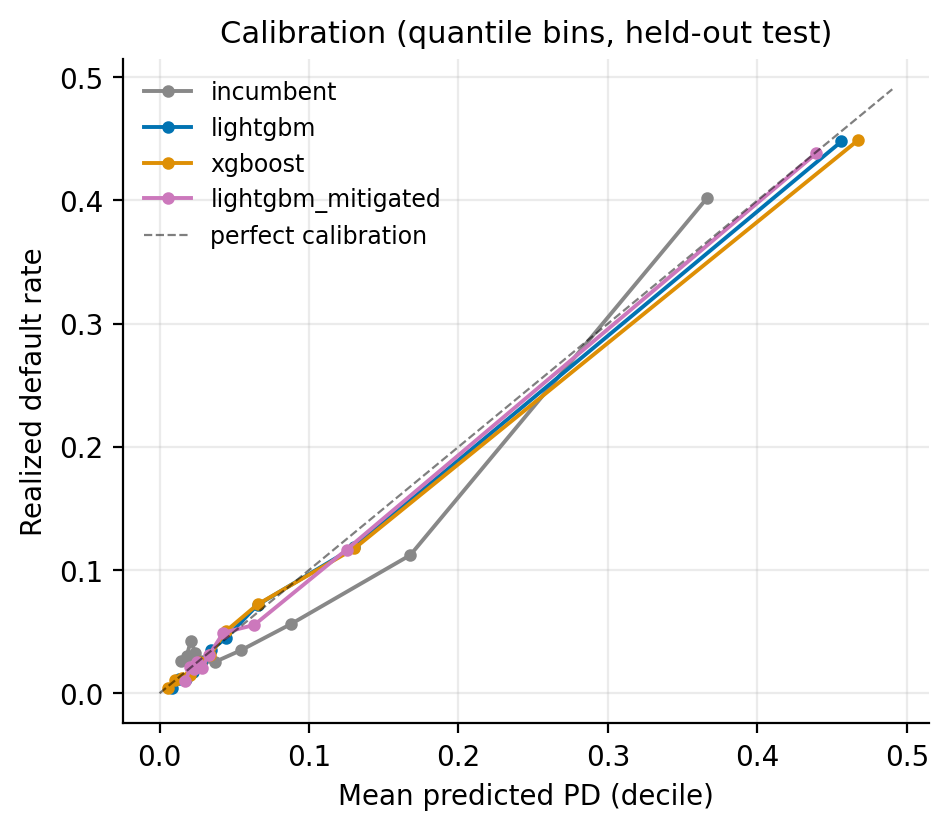

In [6]:
from creditrisk.evaluation import gini as gini_fn
ginis = {m: float(table.loc[m, "gini"]) for m in preds}
viz.plot_roc(y_te, preds, ginis, ROOT/"reports/figures/nb_roc.png")
viz.plot_calibration(y_te, preds, ROOT/"reports/figures/nb_cal.png")
from IPython.display import Image, display
display(Image(str(ROOT/"reports/figures/nb_roc.png"), width=520))
display(Image(str(ROOT/"reports/figures/nb_cal.png"), width=520))

## 3. SHAP explainability and adverse action

Global: which features drive risk, and in which direction. Local: for every declined applicant, the top positive SHAP contributions become ranked **reason codes** — and because SHAP values sum to the actual score margin, the stated reasons are faithful to the decision (the regulatory requirement for adverse-action notices).

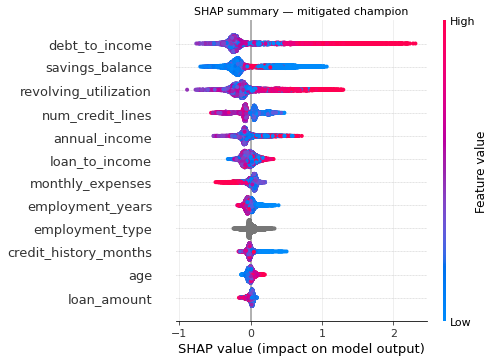

In [7]:
import shap
from creditrisk.explain import tree_shap, adverse_action_reasons, adverse_action_notice
from creditrisk.evaluation import approval_threshold

explainer, Xs, sv = tree_shap(lgbm_fair, test[feats_fair], sample=10_000)
shap.summary_plot(sv, Xs, max_display=12, show=False, plot_size=(7,5))
plt.title("SHAP summary — mitigated champion"); plt.show()

In [8]:
thr = approval_threshold(preds["lightgbm_mitigated"])
declined = np.where(preds["lightgbm_mitigated"] > thr)[0][0]
row = test.iloc[[declined]]
reasons = adverse_action_reasons(explainer, row[feats_fair])
print(adverse_action_notice(row["application_id"].iloc[0],
                            float(preds["lightgbm_mitigated"][declined]), thr, reasons))

ADVERSE ACTION NOTICE (sample, generated for model documentation)
Application ID: 6305
Decision: DECLINED  (model PD 42.47% vs cutoff 5.02%)

Principal reasons for adverse action (per ECOA / Regulation B):
  1. [R02] Debt obligations are too high relative to income
      (applicant value: 0.6552, contribution to risk score: +1.6492)
  2. [R01] Proportion of revolving balances to credit limits is too high
      (applicant value: 0.9425, contribution to risk score: +0.8930)
  3. [R10] Insufficient deposit or savings balances
      (applicant value: 160.0, contribution to risk score: +0.8760)
  4. [R08] Length or stability of employment is insufficient
      (applicant value: contract, contribution to risk score: +0.1500)

You have the right to a statement of specific reasons and to dispute the accuracy of information used in this decision.


## 4. Fairness audit — catching the injected bias

Decisions approve the lowest-PD applicants at a 70% approval rate. Per protected attribute we test the **adverse impact ratio** against the four-fifths rule, equal opportunity (TPR for non-defaulters), and within-group calibration.

Watch `group`: the naive challenger fails — its shiny new feature was pricing group membership.

In [9]:
from creditrisk.fairness import audit
from creditrisk.evaluation import decisions

prot = test[C.PROTECTED_ATTRS].reset_index(drop=True)
summaries = {}
for variant in ["incumbent", "lightgbm", "lightgbm_mitigated"]:
    p = preds[variant]
    appr = decisions(p, approval_threshold(p))
    tables, summary = audit(y_te, p, appr, prot, C.PROTECTED_ATTRS)
    summaries[variant] = summary
    print(f"--- {variant}")
    print(summary[["min_air","demographic_parity_diff","equal_opportunity_diff",
                   "passes_four_fifths"]].round(3), "\n")

--- incumbent
           min_air  demographic_parity_diff  equal_opportunity_diff  \
attribute                                                             
gender       0.996                    0.002                   0.005   
age_band     0.537                    0.463                   0.419   
group        0.931                    0.049                   0.050   

           passes_four_fifths  
attribute                      
gender                   True  
age_band                False  
group                    True   

--- lightgbm
           min_air  demographic_parity_diff  equal_opportunity_diff  \
attribute                                                             
gender       0.994                    0.004                   0.006   
age_band     0.561                    0.439                   0.371   
group        0.762                    0.173                   0.182   

           passes_four_fifths  
attribute                      
gender                   True  
age

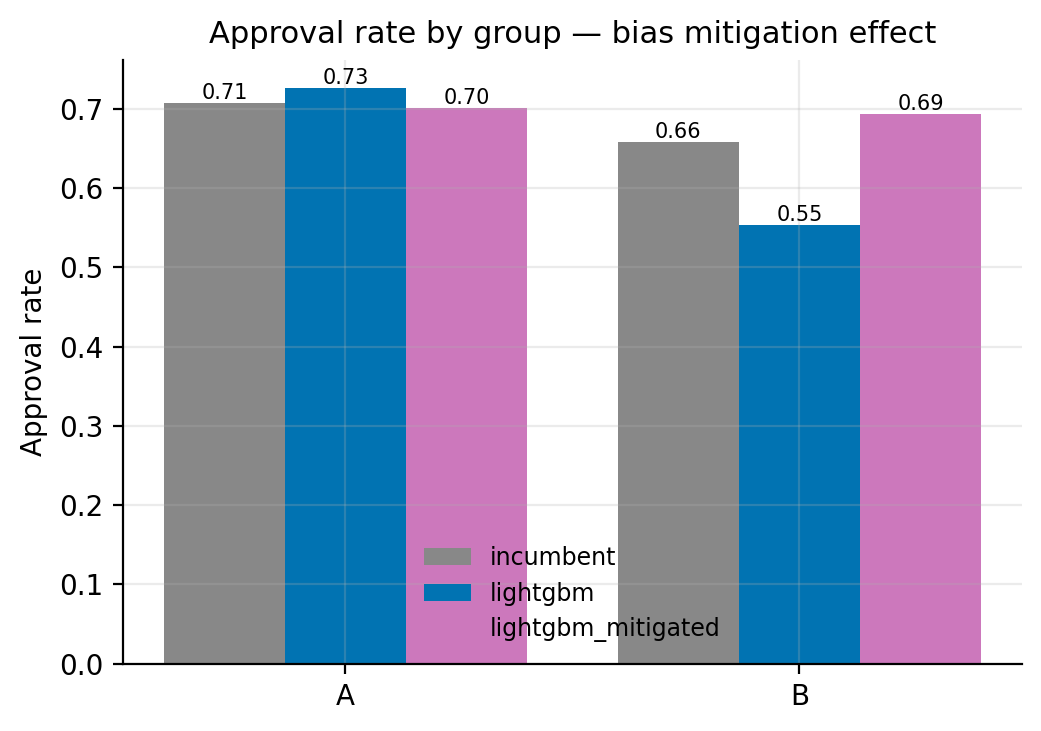

In [10]:
groups_tbl = {}
for variant in ["incumbent","lightgbm","lightgbm_mitigated"]:
    p = preds[variant]
    appr = decisions(p, approval_threshold(p))
    tables, _ = audit(y_te, p, appr, prot, ["group"])
    groups_tbl[variant] = tables
viz.plot_fairness(groups_tbl, "group", ROOT/"reports/figures/nb_fair.png")
display(Image(str(ROOT/"reports/figures/nb_fair.png"), width=560))

Removing `geo_risk_index` restores group B's approval rate (AIR ≈ 0.98) at a modest Gini cost relative to the naive model — while keeping the full lift over the incumbent. Age-band disparities remain, but within-group calibration gaps are ≈ 0: those differences track realized default rates (risk differentiation ECOA permits for empirically derived systems), not model bias. The residual income-measurement bias is documented and monitored (`docs/MONITORING_PLAN.md`).

> The full pipeline also validates the *test suite itself*: with bias knobs at zero, the audit passes; at the default settings it must fail the naive model — and does.

## 5. Business impact — swap-set analysis

In [11]:
from creditrisk.evaluation import business_impact
impact = business_impact(y_te, preds["incumbent"], preds["lightgbm_mitigated"],
                         test["loan_amount"].values)
print(f"At a constant {impact['approval_rate']:.0%} approval rate (annualized to "
      f"{C.ANNUAL_APPLICATIONS:,} applications, LGD {C.LGD}):")
print(f"  incumbent expected annual default losses : ${impact['incumbent_annual_loss']/1e6:,.1f}M")
print(f"  champion expected annual default losses  : ${impact['challenger_annual_loss']/1e6:,.1f}M")
print(f"  annual loss reduction                    : ${impact['annual_loss_reduction']/1e6:,.1f}M "
      f"({impact['loss_reduction_pct']:.1%})")
print(f"  swap-set: {impact['swap_in']:,} swapped in / {impact['swap_out']:,} swapped out")
print(f"At constant risk, approvals expand {impact['approval_rate']:.0%} -> "
      f"{impact['constant_risk_approval_rate']:.1%} "
      f"(+{impact['additional_approvals_annual']:,} approvals/yr)")

At a constant 70% approval rate (annualized to 800,000 applications, LGD 0.55):
  incumbent expected annual default losses : $69.8M
  champion expected annual default losses  : $59.4M
  annual loss reduction                    : $10.5M (15.0%)
  swap-set: 1,887 swapped in / 1,887 swapped out
At constant risk, approvals expand 70% -> 76.3% (+50,258 approvals/yr)


## 6. Full-scale (800K) results and governance artifacts

In [12]:
m = json.loads((ROOT/"reports/metrics.json").read_text())
print(f"run: {m['n_applications']:,} applications | champion: {m['champion']}")
print(f"Gini lift vs incumbent: +{m['gini_lift_vs_incumbent']}")
print(f"annual loss reduction : ${m['business_impact']['annual_loss_reduction']/1e6:.1f}M "
      f"({m['business_impact']['loss_reduction_pct']:.1%})")
print(f"approval expansion    : +{m['business_impact']['additional_approvals_annual']:,}/yr at constant risk")
pd.DataFrame(m["models"]).set_index("model")[["gini","ks","brier","gini_ci_lo","gini_ci_hi","gini_lift_vs_incumbent"]]

run: 800,000 applications | champion: lightgbm_mitigated
Gini lift vs incumbent: +0.1017
annual loss reduction : $13.8M (19.2%)
approval expansion    : +57,998/yr at constant risk


,gini,ks,brier,gini_ci_lo,gini_ci_hi,gini_lift_vs_incumbent
model,,,,,,
incumbent,0.5862,0.5056,0.0592,0.5764,0.5985,0.0000
lightgbm,0.7346,0.5827,0.0515,0.7279,0.7433,0.1484
xgboost,0.7352,0.5817,0.0515,0.7284,0.7434,0.1490
ft_transformer,0.7346,0.5818,0.0518,0.7277,0.7423,0.1484
lightgbm_mitigated,0.6879,0.5605,0.0532,0.6783,0.6986,0.1017


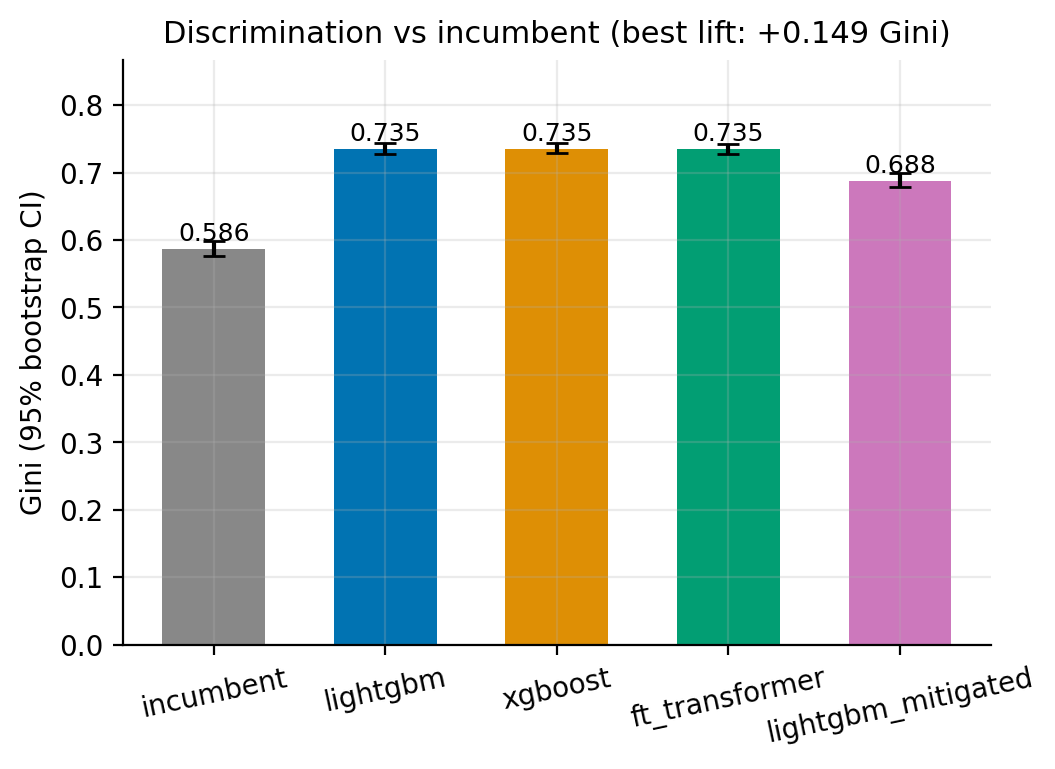

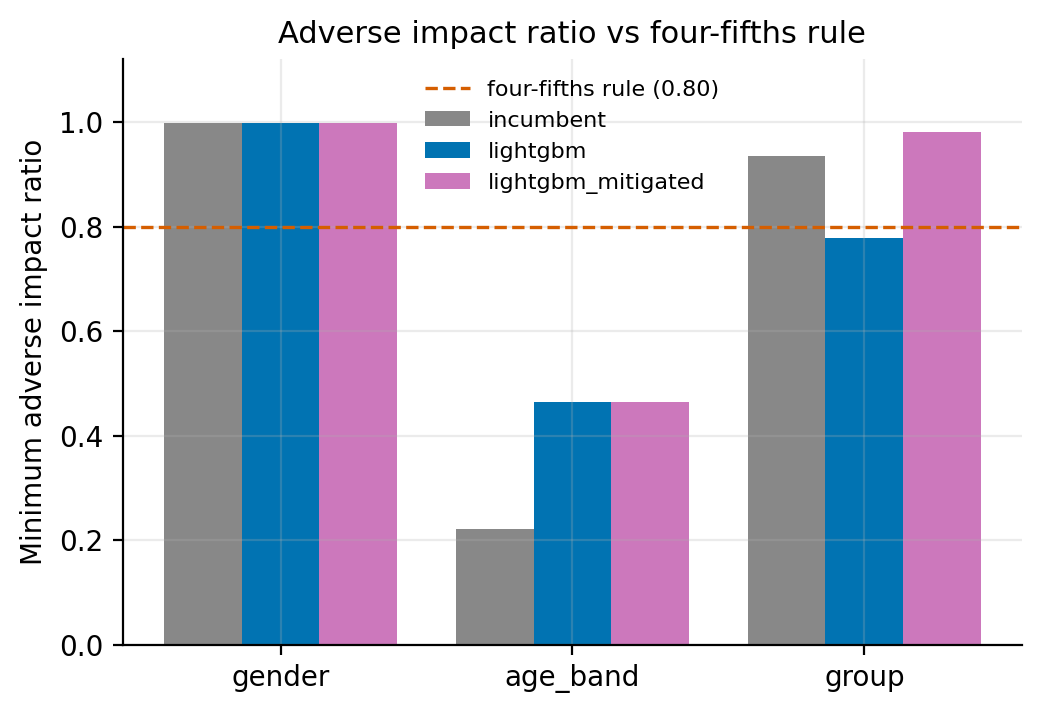

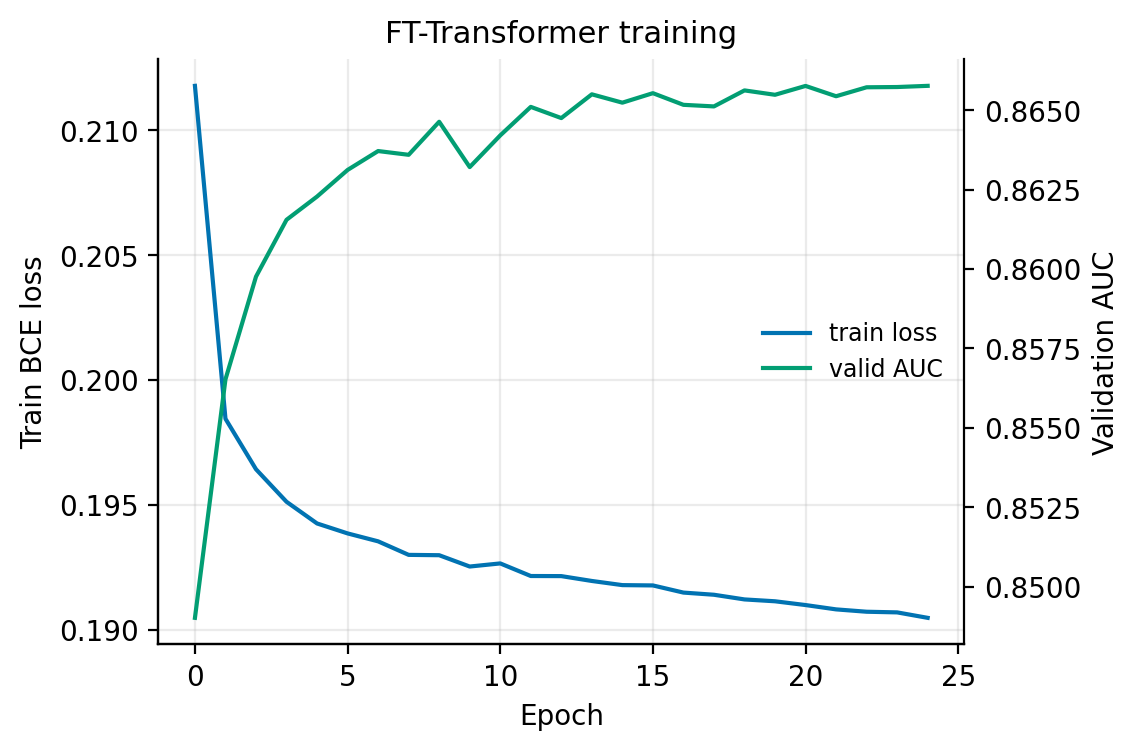

In [13]:
display(Image(str(ROOT/"reports/figures/gini_comparison.png"), width=560))
display(Image(str(ROOT/"reports/figures/adverse_impact_ratio.png"), width=560))
display(Image(str(ROOT/"reports/figures/nn_training.png"), width=480))

## 7. Extended model zoo

Beyond the core four, `scripts/run_model_zoo.py` benchmarks twelve variants under the approved feature policy — CatBoost, random forest, a **monotone-constrained** LightGBM (the regulator-friendly option), an **EBM** glass-box GAM, an **augmented scorecard** with GBM-distilled SHAP-interaction crosses, three from-scratch deep architectures (FT-Transformer, MLP-ResNet, **TabM**), and a stacked ensemble — with uniform Gini/KS/Brier/**ECE**/latency metrics plus an isotonic calibration layer for the champion.

Two findings worth pausing on:

- The **distilled cross terms recover the simulator's true regime interactions** (utilization×credit-lines = the thin-file effect; DTI×utilization = the distressed-revolver effect) — the SHAP-interaction extraction found the actual data-generating structure.
- The **EBM keeps most of the black-box lift while staying fully plottable**, confirming the portfolio's risk is pairwise-interaction-driven — and offering a credible glass-box deployment path if tree ensembles were ever disallowed.

In [14]:
zoo = json.loads((ROOT/"reports/model_zoo/metrics.json").read_text())
zt = pd.DataFrame(zoo["models"]).set_index("model")
print("feature policy:", zoo["feature_policy"])
print("distilled SHAP-interaction crosses:", ", ".join("×".join(p) for p in zoo["shap_distilled_pairs"]))
zt[["family","gini","gini_ci_lo","gini_ci_hi","ks","brier","ece","latency_ms_per_1k","gini_lift_vs_incumbent"]]

feature policy: mitigated (geo_risk_index excluded)
distilled SHAP-interaction crosses: revolving_utilization×num_credit_lines, debt_to_income×revolving_utilization, debt_to_income×savings_balance, annual_income×debt_to_income, revolving_utilization×savings_balance, loan_to_income×savings_balance


,family,gini,gini_ci_lo,gini_ci_hi,ks,brier,ece,latency_ms_per_1k,gini_lift_vs_incumbent
model,,,,,,,,,
stacked_ensemble,ensemble,0.689011,0.6748,0.7039,0.559786,0.053123,0.00181,3.73,0.1028
catboost,GBM,0.688325,0.6746,0.7026,0.558667,0.053158,0.00132,0.69,0.1021
lightgbm_champion,GBM,0.687888,0.6731,0.7039,0.560472,0.053213,0.00221,1.12,0.1016
xgboost,GBM,0.686880,0.6723,0.7016,0.558905,0.053224,0.00187,1.00,0.1006
ft_transformer,deep,0.684653,0.6701,0.6996,0.559325,0.053255,0.00247,7.99,0.0984
ebm,GAM (glass box),0.684503,0.6700,0.6983,0.559081,0.053178,0.00238,1.47,0.0983
random_forest,bagging,0.680897,0.6684,0.6963,0.556679,0.053682,0.00552,1.84,0.0947
tabm,deep,0.677555,0.6642,0.6930,0.553271,0.053880,0.00219,0.88,0.0913
mlp_resnet,deep,0.673608,0.6601,0.6893,0.549177,0.054570,0.01344,0.55,0.0874


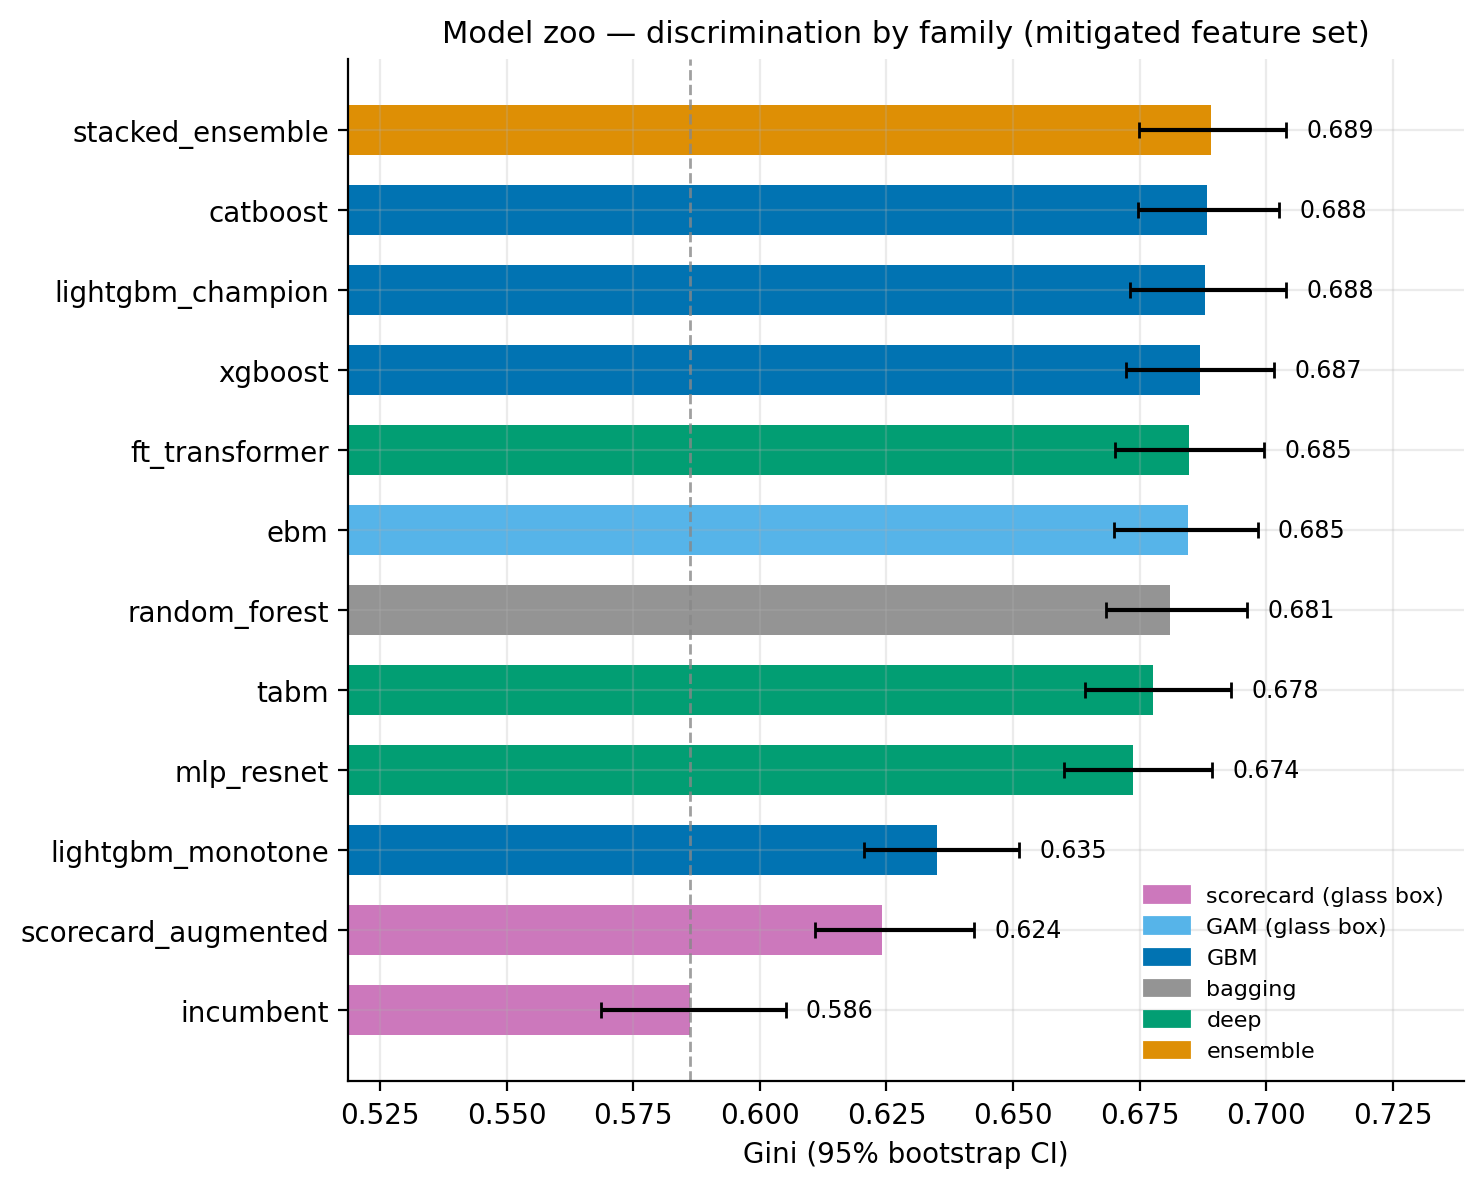

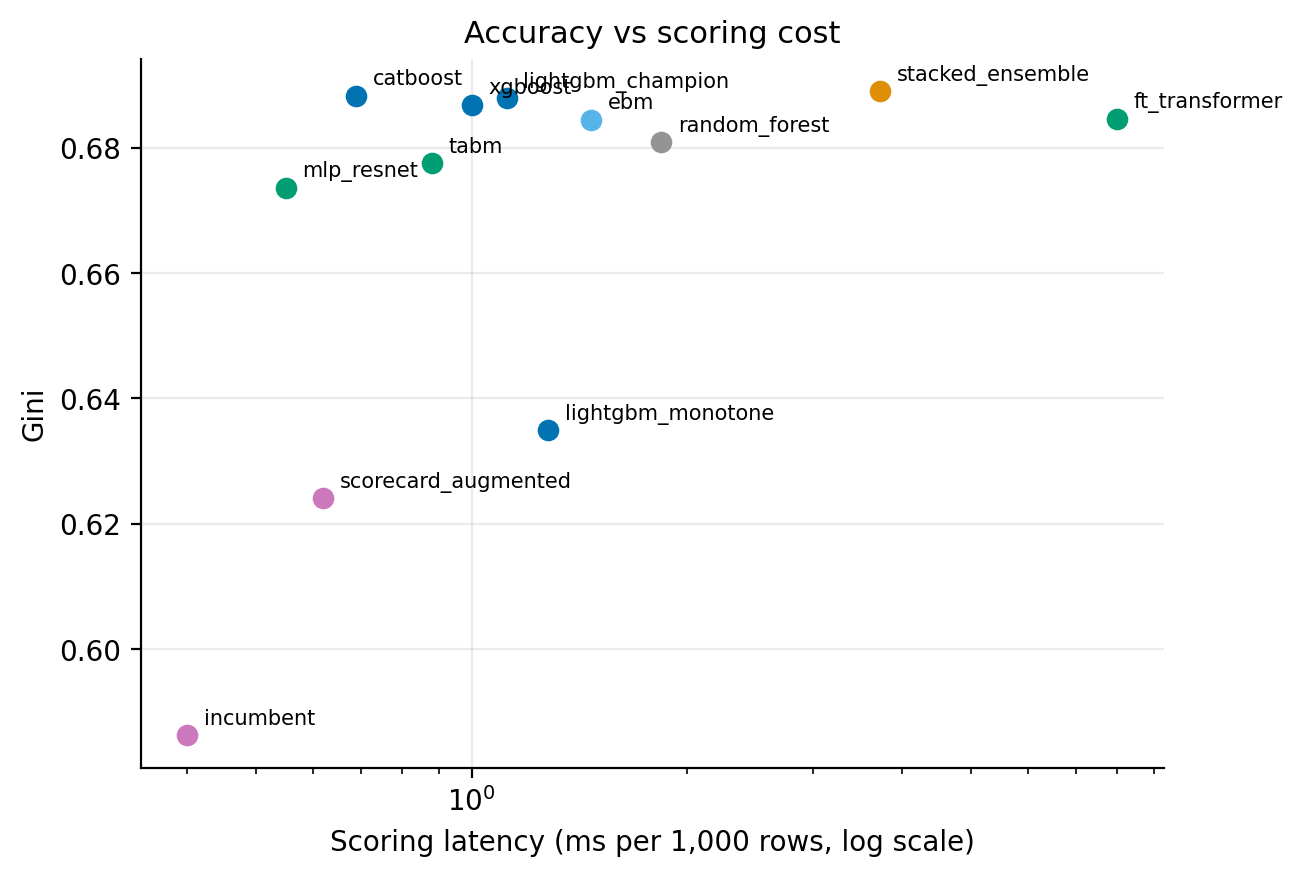

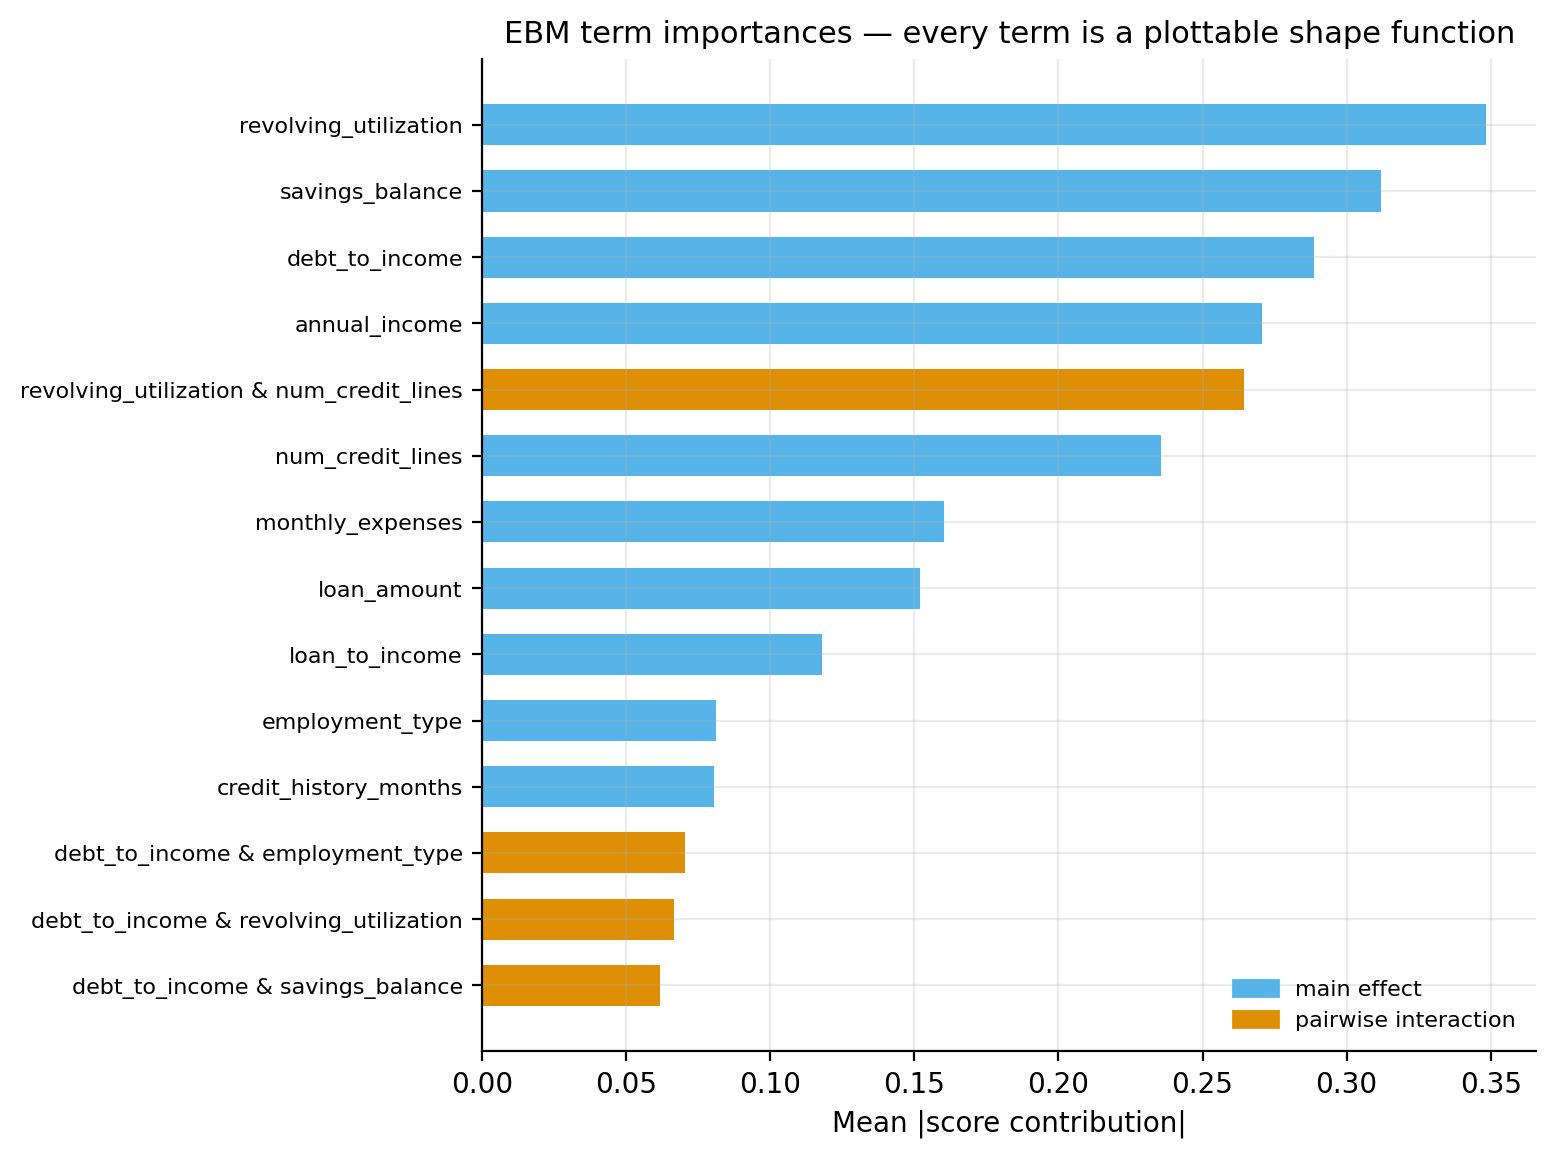

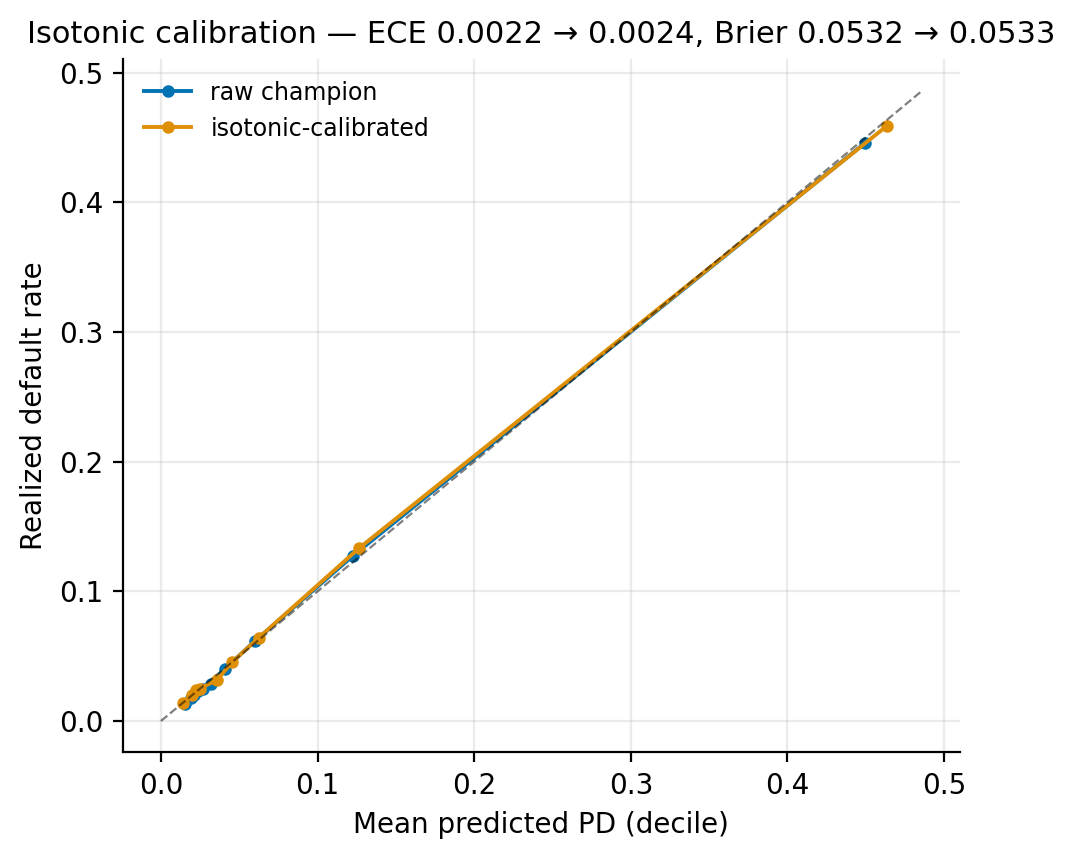

In [15]:
display(Image(str(ROOT/"reports/model_zoo/figures/model_zoo_gini.png"), width=640))
display(Image(str(ROOT/"reports/model_zoo/figures/gini_vs_latency.png"), width=560))
display(Image(str(ROOT/"reports/model_zoo/figures/ebm_terms.png"), width=580))
display(Image(str(ROOT/"reports/model_zoo/figures/calibration_isotonic.png"), width=500))

### Where to go next

- **Governance docs**: [`docs/MODEL_CARD.md`](../docs/MODEL_CARD.md) · [`docs/VALIDATION_REPORT.md`](../docs/VALIDATION_REPORT.md) (SR 11-7 structure) · [`docs/MONITORING_PLAN.md`](../docs/MONITORING_PLAN.md)
- **Generated reports**: [`reports/RESULTS.md`](../reports/RESULTS.md) · [`reports/FAIRNESS_REPORT.md`](../reports/FAIRNESS_REPORT.md) · [`reports/adverse_action_samples.txt`](../reports/adverse_action_samples.txt)
- **Scoring API**: `uvicorn api.main:app` → POST `/score` returns PD, points score, decision and reason codes
- **Real data**: `python scripts/run_home_credit.py` reruns the comparison on Home Credit Default Risk (~307K Kaggle applications)